# 08 Similarity Analysis

This notebook explores track similarity based on the scaled audio features prepared in the previous feature engineering step.

The analysis focuses on:
- loading and preparing the feature matrix
- calculating similarity between tracks
- testing nearest-neighbor style recommendations
- checking whether the selected features produce reasonable results
- identifying possible issues before building the baseline recommender

## 1. Load Data and Prepare Features

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

In [2]:
tracks = con.execute("""
    SELECT *
    FROM tracks
""").df()

tracks.shape

(101939, 32)

## 2. Select Recommendation Features

In [3]:
audio_feature_cols = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
    "duration_ms",
    "popularity"
]

feature_df = tracks[audio_feature_cols].copy()

feature_df.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity
0,0.294,0.698,0.606,0.000003,0.151,-7.447,0.0262,115.018,0.6220,235584.0,28.0
1,0.863,0.719,0.308,0.000000,0.253,-10.340,0.9220,115.075,0.5890,656960.0,31.0
2,0.750,0.466,0.931,0.000000,0.938,-13.605,0.9440,79.565,0.0850,492840.0,31.0
3,0.763,0.719,0.126,0.000000,0.113,-20.254,0.9380,112.822,0.5330,316578.0,14.0
4,0.770,0.460,0.942,0.000000,0.917,-13.749,0.9430,81.260,0.0906,558880.0,32.0


In [4]:
feature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
acousticness,101939.0,0.352124,0.334855,0.0,0.0407,0.238000,0.6450,0.996
danceability,101939.0,0.586015,0.177724,0.0,0.4800,0.610000,0.7140,0.989
energy,101939.0,0.586479,0.260170,0.0,0.4110,0.629000,0.7980,1.000
instrumentalness,101939.0,0.148776,0.304024,0.0,0.0000,0.000037,0.0344,1.000
liveness,101939.0,0.197640,0.175391,0.0,0.0956,0.124000,0.2410,0.999
loudness,101939.0,-9.462720,6.198508,-60.0,-11.1490,-7.599000,-5.5090,2.719
speechiness,101939.0,0.128841,0.203324,0.0,0.0364,0.050600,0.1040,0.969
tempo,101939.0,118.358527,30.224074,0.0,95.9730,118.067000,136.0450,244.035
valence,101939.0,0.482813,0.261690,0.0,0.2710,0.477000,0.6930,0.993
duration_ms,101939.0,246770.803304,190430.295141,1155.0,184000.0000,216893.000000,261055.0000,5505831.000


## 3. Scale Features

In [5]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(feature_df)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=audio_feature_cols
)

scaled_df.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity
0,-0.173579,0.630108,0.075031,-0.489350,-0.265923,0.325196,-0.504821,-0.110526,0.531880,-0.058745,-0.701717
1,1.525671,0.748269,-1.070377,-0.489359,0.315638,-0.141532,3.900983,-0.108640,0.405777,2.154023,-0.523047
2,1.188210,-0.675291,1.324219,-0.489359,4.221220,-0.668274,4.009186,-1.283537,-1.520172,1.292181,-0.523047
3,1.227033,0.748269,-1.769922,-0.489359,-0.482583,-1.740957,3.979676,-0.183184,0.191782,0.366578,-1.535513
4,1.247938,-0.709051,1.366499,-0.489359,4.101486,-0.691505,4.004267,-1.227456,-1.498773,1.638976,-0.463490


In [6]:
scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
acousticness,101939.0,-2.280674e-16,1.000005,-1.051575,-0.930029,-0.340816,0.874640,1.922860
danceability,101939.0,-4.572500e-16,1.000005,-3.297343,-0.596517,0.134957,0.720136,2.267484
energy,101939.0,-3.457256e-17,1.000005,-2.254223,-0.674481,0.163435,0.813013,1.589431
instrumentalness,101939.0,-7.249085e-18,1.000005,-0.489359,-0.489359,-0.489236,-0.376209,2.799876
liveness,101939.0,1.672866e-16,1.000005,-1.126862,-0.581791,-0.419866,0.247219,4.569016
loudness,101939.0,2.737924e-16,1.000005,-8.153176,-0.272047,0.300674,0.637853,1.965276
speechiness,101939.0,-1.106879e-16,1.000005,-0.633680,-0.454654,-0.384814,-0.122178,4.132143
tempo,101939.0,1.315988e-16,1.000005,-3.916054,-0.740656,-0.009646,0.585181,4.158178
valence,101939.0,7.388490e-18,1.000005,-1.844985,-0.809405,-0.022212,0.803195,1.949593
duration_ms,101939.0,-1.819241e-17,1.000005,-1.289800,-0.329628,-0.156897,0.075010,27.616856


Scaling is necessary because similarity methods are sensitive to differences in feature ranges. Without scaling, variables such as duration or tempo could dominate the similarity calculation.

## 4. Create Track Lookup Table

In [7]:
track_lookup = tracks[
    ["id", "name", "artists_id", "popularity"]
].copy()

track_lookup.head()

,id,name,artists_id,popularity
0,5qljLQuKnNJf4F4vfxQB0V,Blood,['3mxJuHRn2ZWD5OofvJtDZY'],28.0
1,3VAX2MJdmdqARLSU5hPMpm,The Ugly Duckling,['4xWMewm6CYMstu0sPgd9jJ'],31.0
2,1L3YAhsEMrGVvCgDXj2TYn,Jimmy Launches His Own Range Of Greetings Cards,['3hYaK5FF3YAglCj5HZgBnP'],31.0
3,6aCe9zzoZmCojX7bbgKKtf,The Crime At Pickets Mill,['2KQsUB9DRBcJk17JWX1eXD'],14.0
4,1Vo802A38tPFHmje1h91um,Setup + Punchline = Joke,['3hYaK5FF3YAglCj5HZgBnP'],32.0


In [8]:
track_lookup.shape

(101939, 4)

In [9]:
track_lookup["name"].value_counts().head(20)

name
Home           45
You            39
Time           28
Breathe        26
Crazy          26
Alive          25
Drive          25
Dreams         23
With You       23
Hold On        23
Lullaby        22
Summertime     22
Without You    21
Heartbeat      21
Love           20
Fuego          20
Runaway        20
Falling        20
Closer         20
Only You       20
Name: count, dtype: int64

Some track names appear multiple times in the dataset. This means that track names alone are not always unique identifiers.

For recommendation purposes, the track ID is more reliable than the track name.

## 5. Test Track Search Function

In [10]:
def search_tracks(query, tracks_df, top_n=10):
    query = query.lower().strip()

    matches = tracks_df[
        tracks_df["name"]
        .str.lower()
        .str.contains(query, na=False)
    ]

    return matches[
        ["id", "name", "artists_id", "popularity"]
    ].head(top_n)

In [11]:
search_tracks("love", track_lookup)

,id,name,artists_id,popularity
106,4YouyrGDNnMiuTpYiUklOc,The Undisputed Champs (feat. Q-Tip of A Tribe ...,"['0YsLR3SQd5QTXAhGIGX7cl', '3ZotbHeyVQKxQCPDJu...",36.0
128,2DvjFThXUY8A87WlKyMwQB,Love & Devotion,['1t6dTIhZsZgxGUHycTVnDZ'],25.0
206,4xVeiS18oLalSFnqRbuWwx,You Love It,['4obzFoKoKRHIphyHzJ35G3'],44.0
207,7Bz8EMztiuSJeHIjrBw7pw,Miss You Love,['4iudEcmuPlYNdbP3e1bdn1'],60.0
214,7jPdY7JO6uvH39lcBYsSzs,Love Theme,['2ABBMkcUeM9hdpimo86mo6'],52.0
255,0xUKmfxvqoZ696QwNXeAyT,En Love,['56oDRnqbIiwx4mymNEv7dS'],48.0
294,7vZXDcSrJRsKutnz2Xt1kQ,As Though from Love,['2svbncjBDEs3nRku3D9w5t'],4.0
301,4sIfw70ttb2miFSLPaKP4O,Big City Love,['62QZPjYQMoo5g56FP9Webq'],38.0
346,0fg0dCPd2fCYoNPoZ40h7z,I'm Still In Love,['5pryfFgCrWJ41UHaENJPyi'],56.0
538,3oBduQTdb5hTfUsBBuCBkE,Love Me Right,"['7suaOI2AMM3ZqTa04oB8fG', '5gVxephJtTx5uMF26Z...",32.0


In [12]:
search_tracks("time", track_lookup)

,id,name,artists_id,popularity
195,63Tl9k1sH8tznn3bqoMuyF,Waka Waka (This Time for Africa) - K-Mix,['0EmeFodog0BfCgMzAIvKQp'],47.0
337,4jitHM87wUT8kkRNgU0bVA,Wasted Time,['2PyT97wbUZvF6clgcl91cU'],30.0
343,45ILRUmP1nrs2TyAj42lAe,"Divertimento in D Major, K. 136, ""Salzburg Sym...","['4NJhFmfw43RLBLjQvxDuRS', '3COykW4UPvB0Dqwnzl...",26.0
411,6acUcpLOd1rTiZsKRYRkdB,Summertime,['7K1kLxBi5jTA3fdsQ6Wcmt'],36.0
435,0SxFyA4FqmEQqZVuAlg8lf,The First Time Ever I Saw Your Face,['0W498bDDNlJIrYMKXdpLHA'],62.0
510,0KrWEPKsFiOEmNZz5suMIZ,The Well Of Time,['3z6OaFpSGrLQmmDtvL0Zyr'],47.0
748,33zBEW0jzjTLKYDYtEnOtX,Sometimes,['1LhB1j0Zq3tjBeG3k8gq7V'],44.0
951,3CHe25YNFuNN6D7syxg7lZ,Alien Time Machine,['7qv98X8sMufCfmdikGYp6U'],22.0
1071,5SNaJ5ZufmrJ2ZqQzQD6Xn,"Divertimento in D Major, Op. 34, No. 3: I. Poc...","['07GFs4QjIiUspOwYP24qP5', '73lnfmOyEVgdb1cThX...",26.0
1075,7DPeDHon3uZJvPzQAfvrTH,"Divertimento in C Major, Hob. III:6: I. Presto...","['656RXuyw7CE0dtjdPgjJV6', '17Zub3zauD3GIUBg9T...",22.0


## 6. Cosine Similarity Test

In [13]:
# Calculate cosine similarity for a smaller sample first
# This avoids creating a huge 101,939 x 101,939 similarity matrix.

sample_size = 10000

sample_tracks = track_lookup.sample(
    n=sample_size,
    random_state=42
).reset_index(drop=False)

sample_indices = sample_tracks["index"].values

sample_features = scaled_df.iloc[sample_indices]

similarity_matrix = cosine_similarity(sample_features)

similarity_matrix.shape

(10000, 10000)

A sample is used for the first similarity test because calculating a full similarity matrix for more than 100,000 tracks would be memory-intensive.

## 7. Similar Tracks Function

In [14]:
def get_similar_tracks(track_name, sample_tracks, similarity_matrix, top_n=10):
    matches = sample_tracks[
        sample_tracks["name"]
        .str.lower()
        .str.contains(track_name.lower().strip(), na=False)
    ]

    if matches.empty:
        return "Track not found in sample."

    selected_index = matches.index[0]

    similarity_scores = list(enumerate(similarity_matrix[selected_index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    top_matches = similarity_scores[1:top_n + 1]

    result_indices = [i[0] for i in top_matches]
    result_scores = [i[1] for i in top_matches]

    results = sample_tracks.iloc[result_indices][
        ["id", "name", "artists_id", "popularity"]
    ].copy()

    results["similarity_score"] = result_scores

    return results

In [15]:
get_similar_tracks(
    "love",
    sample_tracks,
    similarity_matrix,
    top_n=10
)

,id,name,artists_id,popularity,similarity_score
2453,0SLHoGP4ISrtaVzwOq9HnK,Filmen om oss,['7IK2JpZglDYTrso4ILEKE0'],30.0,0.957969
7628,4OXDxLCmy0m2IFam4W6K3n,Stay Close,['6C2OWSuRcg7cZL4fsAJ3No'],43.0,0.947705
1388,7gL5kaZBt8226yjXBTxzjV,Cabecinha No Ombro,['2JnNhPT0sQvhKOyLqDKRuP'],49.0,0.916592
6349,54whmtPE736Lh8t0cjrihv,Liar Liar - Recorded at Spotify Studios NYC,['27IiEYV6p8fs5j8n39Pk1u'],35.0,0.914967
3670,2BH2Y14TPW05LtVoxEkX7R,Não Quero Parar,['0Z3J1nYuQunKAqOeVmRXeX'],34.0,0.913865
4985,1hDQtWimXaHNYH1YIrIs4v,Incontrolable Amor,['2TkDdk47FGnvxcjQGDdPd0'],42.0,0.906854
135,4QNrjlYBBQjoY6ViwDPjOI,Paperboy,['5iuXjsXsTXs8lwmqzsF6dZ'],34.0,0.905493
8015,3gMrH8OIROYCrFskiBaNsA,It Hurts Like Hell,['7nwUJBm0HE4ZxD3f5cy5ok'],43.0,0.905072
4623,2rwxsA3kNJj8ycasZGU1DS,Can't Show My Face,['1I9HNoVK6kOQGVZfulXVnm'],36.0,0.897753
6895,4SI0s0tgVRcqGzp6BjCegc,Over All I Know,['6N6Sk9XOoHsadAGYR44C2o'],39.0,0.897654


In [16]:
get_similar_tracks(
    "time",
    sample_tracks,
    similarity_matrix,
    top_n=10
)

,id,name,artists_id,popularity,similarity_score
6577,52tGZbGFCfWAxkkmroPaqA,Intelligent Worship,['1TKaUU8ooBgSW9TlyKsw6k'],44.0,0.949264
2554,6Nku7JNuxk9PvZmaHJUjVw,Show Me Love,"['10gzBoINW3cLJfZUka8Zoe', '0SfsnGyD8FpIN4U4WC...",39.0,0.912676
5244,1OiH98JsBCO7OIlpK058Bn,Corazón,['2S1RZNDZE0W1pt57ytr1dh'],32.0,0.912591
5007,2nWjhmRImt6LScZIPQMBnM,Sex Type Thing,['2UazAtjfzqBF0Nho2awK4z'],54.0,0.900499
3589,7fxpqs4G8vj3rFYbJnsG7w,Shitlist,['2zMQOJ4Cyl4BYbw6WqaO3h'],48.0,0.898588
1605,32dTnE7cWjEHCUAjSEvpiM,Break Down the Walls,['0DbBwI2dpYty5Tl7bdSIjL'],36.0,0.888566
6390,4XoLM5pbS7zLx5NbL4v790,If I'm Gone Tomorrow (It's Because of Aliens),['0JnhdXEQfVjoY1OgwTExwO'],45.0,0.881433
8591,3sCMBiy5PPpAyhC6JmcU7X,Mi Niña,['0xg0tZofneUYpE1HQS4gOg'],35.0,0.868615
4550,4tTRkFBRZTkxdKk3Om379g,Lost In A Reverie,['7kzcU2VstxyIv6Lc6R4vNM'],35.0,0.863951
9388,4iq4RFWmQc3zFgBgyrpahF,Never Going Home,['1nEGjL7aMVdNQzsfQPKdGr'],52.0,0.861233


## 8. Interpretations

The cosine similarity analysis shows that the selected audio features can identify tracks with very similar numerical profiles. Some highly similar pairs are duplicate or near-duplicate versions of the same song, which suggests that the similarity approach is working technically.

However, the results also reveal an important limitation: the dataset contains spoken-word, episode-like, and audiobook-style tracks. These entries can appear as highly similar because they share similar audio-feature patterns, even if they are not musically similar in the usual sense.

This means that a future recommender should consider additional filtering or metadata rules to separate standard music tracks from spoken-word content.

## 9. Similarity Score Distribution

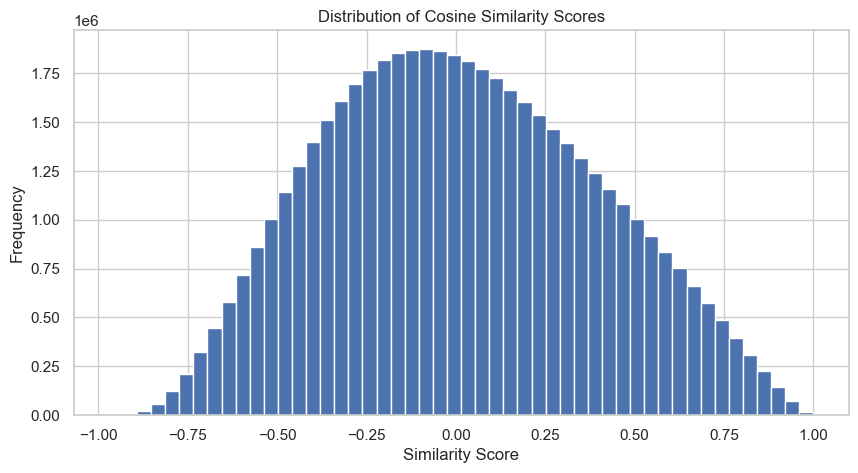

In [17]:
# Flatten similarity matrix (excluding diagonal/self-similarity)

similarity_values = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]

plt.figure(figsize=(10, 5))

plt.hist(similarity_values, bins=50)

plt.title("Distribution of Cosine Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")

plt.show()

## 10. Most Similar Track Pairs

In [18]:
# Convert upper triangle of similarity matrix into indices

upper_triangle = np.triu_indices_from(similarity_matrix, k=1)

scores = similarity_matrix[upper_triangle]

# Get indices of top similarity scores

top_n = 10

top_score_indices = np.argsort(scores)[-top_n:][::-1]

top_results = []

for idx in top_score_indices:

    i = upper_triangle[0][idx]
    j = upper_triangle[1][idx]

    top_results.append({
        "track_1": sample_tracks.iloc[i]["name"],
        "track_2": sample_tracks.iloc[j]["name"],
        "similarity_score": similarity_matrix[i, j]
    })

top_pairs_df = pd.DataFrame(top_results)

top_pairs_df

,track_1,track_2,similarity_score
0,Kaban no Naka no Yakimochi,鞄の中のやきもち,1.000000
1,The Call of Cthulhu - Part 1 By HP Lovecraft,The Call Of Cthulhu - Part 2,0.999578
2,Evan Finds the Third Room,Evan Finds the Third Room,0.999348
3,Kyoto,Kyoto,0.999340
4,Episode 4,The Red and the Black,0.998948
5,Broccoli (feat. Lil Yachty),Broccoli,0.998935
6,Easily,Easily,0.998881
7,Please Write It Down Please Go And Ask,Would You Write Out The Directions Please?,0.998710
8,Let's Talk About the Bath,Hilary Knight - Commentary 4,0.998699
9,The Yellow Wallpaper,How to Get The Job You Want and Keep It,0.998500


## 11. Similarity vs Popularity

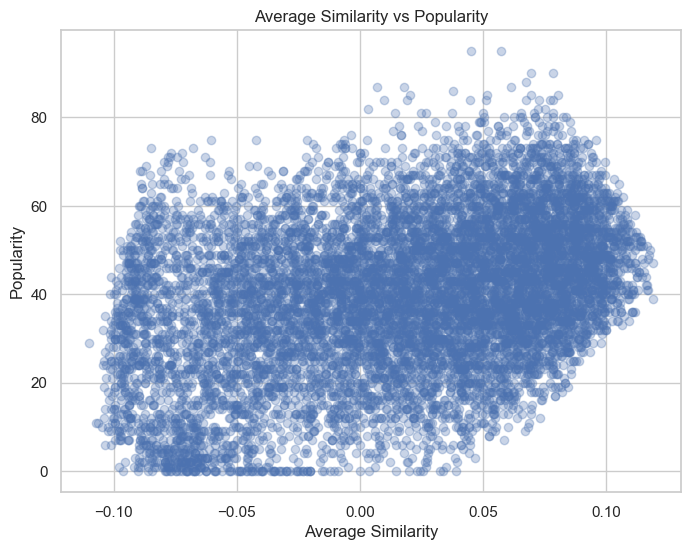

In [19]:
# Average similarity per track

avg_similarity = similarity_matrix.mean(axis=1)

similarity_popularity_df = pd.DataFrame({
    "avg_similarity": avg_similarity,
    "popularity": sample_tracks["popularity"].values
})

plt.figure(figsize=(8, 6))

plt.scatter(
    similarity_popularity_df["avg_similarity"],
    similarity_popularity_df["popularity"],
    alpha=0.3
)

plt.title("Average Similarity vs Popularity")
plt.xlabel("Average Similarity")
plt.ylabel("Popularity")

plt.show()

The relationship between average similarity and popularity appears weak. This suggests that popularity does not directly determine whether a track is similar to many other tracks in the feature space.

For recommendation purposes, popularity can still be useful as an additional ranking signal, but it should not be the only criterion.

## 12. Save Processed Features

In [21]:
# Final processed dataset for future recommender models

processed_tracks = scaled_df.copy()

processed_tracks["track_name"] = tracks["name"].values
processed_tracks["track_id"] = tracks["id"].values

processed_tracks.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity,track_name,track_id
0,-0.173579,0.630108,0.075031,-0.489350,-0.265923,0.325196,-0.504821,-0.110526,0.531880,-0.058745,-0.701717,Blood,5qljLQuKnNJf4F4vfxQB0V
1,1.525671,0.748269,-1.070377,-0.489359,0.315638,-0.141532,3.900983,-0.108640,0.405777,2.154023,-0.523047,The Ugly Duckling,3VAX2MJdmdqARLSU5hPMpm
2,1.188210,-0.675291,1.324219,-0.489359,4.221220,-0.668274,4.009186,-1.283537,-1.520172,1.292181,-0.523047,Jimmy Launches His Own Range Of Greetings Cards,1L3YAhsEMrGVvCgDXj2TYn
3,1.227033,0.748269,-1.769922,-0.489359,-0.482583,-1.740957,3.979676,-0.183184,0.191782,0.366578,-1.535513,The Crime At Pickets Mill,6aCe9zzoZmCojX7bbgKKtf
4,1.247938,-0.709051,1.366499,-0.489359,4.101486,-0.691505,4.004267,-1.227456,-1.498773,1.638976,-0.463490,Setup + Punchline = Joke,1Vo802A38tPFHmje1h91um


In [23]:
processed_tracks.to_csv(
    "../data/processed/scaled_audio_features.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [24]:
con.close()